<a href="https://colab.research.google.com/github/rabia28k/Manav-Yapay-Zeka-YOLOv8/blob/main/yenimanavproje.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# [PROJE NOTU] Market asistanının görmesini sağlayan YOLO kütüphanesini kuruyorum.
%pip install ultralytics
import ultralytics
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
import os
from collections import Counter
import glob
import random

print("✅ Kütüphaneler kuruldu, hazırız.")

✅ Kütüphaneler kuruldu, hazırız.


In [ ]:
# [PROJE NOTU] Veri setime ve model dosyalarıma ulaşmak için Drive'ı bağlıyorum.
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# [PROJE NOTU] Yeni 'Proje_Ham_Veriler2' klasöründeki verileri master_dataset'e topluyorum.
import os
import shutil

# 1. Hedef klasörleri oluşturdum
master_path = '/content/master_dataset'
for split in ['train', 'valid']:
    os.makedirs(f"{master_path}/{split}/images", exist_ok=True)
    os.makedirs(f"{master_path}/{split}/labels", exist_ok=True)

# 2. Yeni Drive yolu
base_drive = '/content/drive/MyDrive/Proje_Ham_Veriler2'

folders = ['00_Patlican', '01_Muz', '02_Patates', '03_Havuc', '04_Salatalik', '05_Curuk_Muz']

print("🚀 Yeni veri setinden aktarım başladı...")

for folder in folders:
    for split in ['train', 'valid']:

        img_src = os.path.join(base_drive, folder, split, 'images')
        lbl_src = os.path.join(base_drive, folder, split, 'labels')

        if os.path.exists(img_src) and os.path.exists(lbl_src):
            # Resimleri kopyalama
            for file in os.listdir(img_src):
                if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                    shutil.copy(os.path.join(img_src, file), f"{master_path}/{split}/images/{folder}_{file}")
            # Etiketleri kopyalama
            for file in os.listdir(lbl_src):
                if file.lower().endswith('.txt'):
                    shutil.copy(os.path.join(lbl_src, file), f"{master_path}/{split}/labels/{folder}_{file}")
            print(f"✅ {folder} ({split}) başarıyla aktarıldı.")
        else:
            print(f"⚠️ Hata: {folder} içinde '{split}' bulunamadı. Lütfen Drive klasör yapısını kontrol et!")

print("\n" + "="*40)
print(f"📂 Yeni Train Resmi: {len(os.listdir(master_path+'/train/images'))}")
print(f"📂 Yeni Valid Resmi: {len(os.listdir(master_path+'/valid/images'))}")
print("="*40)

🚀 Yeni veri setinden aktarım başladı...
✅ 00_Patlican (train) başarıyla aktarıldı.
✅ 00_Patlican (valid) başarıyla aktarıldı.
✅ 01_Muz (train) başarıyla aktarıldı.
✅ 01_Muz (valid) başarıyla aktarıldı.
✅ 02_Patates (train) başarıyla aktarıldı.
✅ 02_Patates (valid) başarıyla aktarıldı.
✅ 03_Havuc (train) başarıyla aktarıldı.
✅ 03_Havuc (valid) başarıyla aktarıldı.
✅ 04_Salatalik (train) başarıyla aktarıldı.
✅ 04_Salatalik (valid) başarıyla aktarıldı.
✅ 05_Curuk_Muz (train) başarıyla aktarıldı.
✅ 05_Curuk_Muz (valid) başarıyla aktarıldı.

📂 Yeni Train Resmi: 6761
📂 Yeni Valid Resmi: 1000


In [ ]:
# [PROJE NOTU] Sınıf dağılımını analiz ediyorum.
# Her meyvenin yeterli veriye sahip olması asistanın güvenilirliği için kritiktir.
from collections import Counter

class_names = ['patlican', 'muz', 'patates', 'havuc', 'salatalik', 'curuk_muz']
label_path = '/content/master_dataset/train/labels'
all_ids = []

for file in os.listdir(label_path):
    with open(os.path.join(label_path, file), 'r') as f:
        for line in f:
            all_ids.append(line.split()[0])

counts = Counter(all_ids)
print("📊 SINIF BAZLI VERİ MİKTARI:")
for i, name in enumerate(class_names):
    print(f"🔹 {name:12}: {counts.get(str(i), 0)} etiket")

📊 SINIF BAZLI VERİ MİKTARI:
🔹 patlican    : 17307 etiket
🔹 muz         : 0 etiket
🔹 patates     : 0 etiket
🔹 havuc       : 0 etiket
🔹 salatalik   : 0 etiket
🔹 curuk_muz   : 0 etiket


In [ ]:
# [PROJE NOTU] Sınıf ID'lerini (0,1,2,3,4,5) klasör sırasına göre yeniden mühürleyerek birleştiriyorum.
import os
import shutil

# 1. Master klasörünü sıfırdan kurdum
master_path = '/content/master_dataset'
if os.path.exists(master_path):
    shutil.rmtree(master_path)

for p in ['train/images', 'train/labels', 'valid/images', 'valid/labels']:
    os.makedirs(os.path.join(master_path, p), exist_ok=True)

# 2. Drive yollarını ve sınıfları tanımladım.
base_drive = '/content/drive/MyDrive/Proje_Ham_Veriler2'
folders = ['00_Patlican', '01_Muz', '02_Patates', '03_Havuc', '04_Salatalik', '05_Curuk_Muz']

print("🚀 Sınıf ID düzeltme ve kopyalama işlemi başladı...")

for idx, folder in enumerate(folders):
    for split in ['train', 'valid']:
        img_src = os.path.join(base_drive, folder, split, 'images')
        lbl_src = os.path.join(base_drive, folder, split, 'labels')

        if os.path.exists(img_src) and os.path.exists(lbl_src):
            # Resimleri kopyalama
            for file in os.listdir(img_src):
                if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                    shutil.copy(os.path.join(img_src, file), f"{master_path}/{split}/images/{folder}_{file}")

            # Etiketleri oku, ID'yi düzelt ve kaydet
            for file in os.listdir(lbl_src):
                if file.lower().endswith('.txt'):
                    with open(os.path.join(lbl_src, file), 'r') as f:
                        lines = f.readlines()

                    corrected_lines = []
                    for line in lines:
                        parts = line.split()
                        if len(parts) > 0:
                            parts[0] = str(idx) # Dosyanın içindeki yanlış ID'yi  değiştirdim
                            corrected_lines.append(" ".join(parts))

                    with open(f"{master_path}/{split}/labels/{folder}_{file}", 'w') as f:
                        f.write("\n".join(corrected_lines))

            print(f"✅ {folder} ({split}) aktarıldı. Atanan ID: {idx}")

print("\n" + "="*50)
print("🎯 TÜM SINIFLAR BİRBİRİNDEN AYRILDI VE DOĞRU ETİKETLENDİ!")
print(f"📂 Toplam Train Resmi: {len(os.listdir(master_path+'/train/images'))}")
print("="*50)

🚀 Sınıf ID düzeltme ve kopyalama işlemi başladı...
✅ 00_Patlican (train) aktarıldı. Atanan ID: 0
✅ 00_Patlican (valid) aktarıldı. Atanan ID: 0
✅ 01_Muz (train) aktarıldı. Atanan ID: 1
✅ 01_Muz (valid) aktarıldı. Atanan ID: 1
✅ 02_Patates (train) aktarıldı. Atanan ID: 2
✅ 02_Patates (valid) aktarıldı. Atanan ID: 2
✅ 03_Havuc (train) aktarıldı. Atanan ID: 3
✅ 03_Havuc (valid) aktarıldı. Atanan ID: 3
✅ 04_Salatalik (train) aktarıldı. Atanan ID: 4
✅ 04_Salatalik (valid) aktarıldı. Atanan ID: 4
✅ 05_Curuk_Muz (train) aktarıldı. Atanan ID: 5
✅ 05_Curuk_Muz (valid) aktarıldı. Atanan ID: 5

🎯 TÜM SINIFLAR BİRBİRİNDEN AYRILDI VE DOĞRU ETİKETLENDİ!
📂 Toplam Train Resmi: 6761


In [ ]:
# [PROJE NOTU] Sınıf dağılımını analiz ediyorum.
# Her meyvenin yeterli veriye sahip olması asistanın güvenilirliği için kritiktir.
from collections import Counter

class_names = ['patlican', 'muz', 'patates', 'havuc', 'salatalik', 'curuk_muz']
label_path = '/content/master_dataset/train/labels'
all_ids = []

for file in os.listdir(label_path):
    with open(os.path.join(label_path, file), 'r') as f:
        for line in f:
            all_ids.append(line.split()[0])

counts = Counter(all_ids)
print("📊 SINIF BAZLI VERİ MİKTARI:")
for i, name in enumerate(class_names):
    print(f"🔹 {name:12}: {counts.get(str(i), 0)} etiket")

📊 SINIF BAZLI VERİ MİKTARI:
🔹 patlican    : 1292 etiket
🔹 muz         : 2088 etiket
🔹 patates     : 9458 etiket
🔹 havuc       : 1970 etiket
🔹 salatalik   : 1455 etiket
🔹 curuk_muz   : 1044 etiket


In [ ]:
# [PROJE NOTU] Oversampling: Az olan meyve sınıflarını veri artırma ile çoğaltıyorum.
import cv2
import numpy as np
import os
import random
import shutil
def augment_image(image):
    # Rastgele döndürme (-15 ile +15 derece arası)
    angle = random.randint(-15, 15)
    h, w = image.shape[:2]
    M = cv2.getRotationMatrix2D((w//2, h//2), angle, 1)
    image = cv2.warpAffine(image, M, (w, h))

    # Rastgele parlaklık değişimi
    brightness = random.uniform(0.7, 1.3)
    image = cv2.convertScaleAbs(image, alpha=brightness, beta=0)

    return image

train_path = '/content/master_dataset/train'
class_names = ['patlican', 'muz', 'patates', 'havuc', 'salatalik', 'curuk_muz']

print("🚀 Veri artırma (Oversampling) işlemi başladı...")

for idx, name in enumerate(class_names):
    if name == 'patates': continue  # Patates zaten çok fazla, onu geçiyoruz

    img_dir = f"{train_path}/images"
    lbl_dir = f"{train_path}/labels"

    # Bu sınıfa ait dosyaları bul
    target_files = [f for f in os.listdir(lbl_dir) if f.startswith(f"0{idx}" if idx < 10 else str(idx))]

    # Mevcut sayıyı yaklaşık 3 katına çıkarttım
    for file_name in target_files:
        img_name = file_name.replace('.txt', '.jpg')
        if not os.path.exists(os.path.join(img_dir, img_name)):
            img_name = img_name.replace('.jpg', '.png')

        if os.path.exists(os.path.join(img_dir, img_name)):
            # Orijinal resmi oku
            img = cv2.imread(os.path.join(img_dir, img_name))
            if img is None: continue

            # 2 adet yeni artırılmış versiyon üret
            for i in range(2):
                aug_img = augment_image(img)
                new_name = f"aug_{i}_{img_name}"

                # Yeni resmi ve etiketi kaydet
                cv2.imwrite(os.path.join(img_dir, new_name), aug_img)
                shutil.copy(os.path.join(lbl_dir, file_name), os.path.join(lbl_dir, new_name.replace('.jpg', '.txt').replace('.png', '.txt')))

    print(f"✅ {name.capitalize()} sınıfı artırıldı.")

print("\n🎉 İşlem tamam! Az olan sınıfların veri miktarı yaklaşık 3 katına çıktı.")

🚀 Veri artırma (Oversampling) işlemi başladı...
✅ Patlican sınıfı artırıldı.
✅ Muz sınıfı artırıldı.
✅ Havuc sınıfı artırıldı.
✅ Salatalik sınıfı artırıldı.
✅ Curuk_muz sınıfı artırıldı.

🎉 İşlem tamam! Az olan sınıfların veri miktarı yaklaşık 3 katına çıktı.


In [ ]:
# [PROJE NOTU] Oversampling sonrası son sınıf sayımını yapıyorum.
# Amacım, patates baskınlığını (bias) kırmış olduğumuzu tescillemek.
from collections import Counter
import os

class_names = ['patlican', 'muz', 'patates', 'havuc', 'salatalik', 'curuk_muz']
all_ids = []

label_dir = '/content/master_dataset/train/labels'
for file in os.listdir(label_dir):
    with open(os.path.join(label_dir, file), 'r') as f:
        for line in f:
            all_ids.append(line.split()[0])

counts = Counter(all_ids)
print("🚀 YENİ VERİ SETİ ANALİZİ (ARTIRILMIŞ):")
print("-" * 45)
for i, name in enumerate(class_names):
    miktar = counts.get(str(i), 0)
    print(f"🔹 {name:12}: {miktar:<6} etiket")
print("-" * 45)
print(f"📈 Toplam Eğitim Verisi: {len(all_ids)}")

🚀 YENİ VERİ SETİ ANALİZİ (ARTIRILMIŞ):
---------------------------------------------
🔹 patlican    : 3876   etiket
🔹 muz         : 6264   etiket
🔹 patates     : 9458   etiket
🔹 havuc       : 5910   etiket
🔹 salatalik   : 4365   etiket
🔹 curuk_muz   : 3132   etiket
---------------------------------------------
📈 Toplam Eğitim Verisi: 33005


In [ ]:
# [PROJE NOTU] 2. Aşama: Gerçek dünya koşullarını (sallantı, gürültü) simüle ediyorum.
import cv2
import numpy as np
import os
import random
import shutil

def aggressive_augment(image):
    # 1. Rastgele Perspektif (Telefonun eğik tutulması)
    h, w = image.shape[:2]
    pts1 = np.float32([[0,0],[w,0],[0,h],[w,h]])
    offset = random.randint(15, 40) # Biraz daha belirgin yaptık
    pts2 = np.float32([[offset, offset], [w-offset, offset], [offset, h-offset], [w-offset, h-offset]])
    M = cv2.getPerspectiveTransform(pts1, pts2)
    image = cv2.warpPerspective(image, M, (w, h))

    # 2. Gauss Gürültüsü (Düşük ışık gürültüsü)
    noise = np.random.normal(0, 15, image.shape).astype(np.uint8)
    image = cv2.add(image, noise)

    # 3. Hareket Bulanıklığı (El titremesi)
    kernel_size = random.choice([5, 7]) # Titremeyi biraz daha artırdım.
    kernel = np.zeros((kernel_size, kernel_size))
    kernel[int((kernel_size-1)/2), :] = np.ones(kernel_size)
    kernel /= kernel_size
    image = cv2.filter2D(image, -1, kernel)

    return image

train_path = '/content/master_dataset/train'

class_names = ['00_Patlican', '01_Muz', '02_Patates', '03_Havuc', '04_Salatalik', '05_Curuk_Muz']

print("🔥 Agresif Veri Artırma Başladı (Zorlu Koşullar Simüle Ediliyor)...")

for idx, folder_name in enumerate(class_names):
    if 'Patates' in folder_name: continue # Patates zaten yeterli

    img_dir = f"{train_path}/images"
    lbl_dir = f"{train_path}/labels"

    # Bu sınıfa ait TÜM etiketleri bul
    target_files = [f for f in os.listdir(lbl_dir) if f.startswith(folder_name) or f.startswith(f"aug_0_{folder_name}") or f.startswith(f"aug_1_{folder_name}")]

    print(f"🛠️ {folder_name} için zorlu varyasyonlar üretiliyor... ({len(target_files)} dosya işlenecek)")

    for file_name in target_files:
        # Resim dosyasını bul
        img_base = file_name.rsplit('.', 1)[0]
        img_name = None
        for ext in ['.jpg', '.jpeg', '.png', '.JPG']:
            if os.path.exists(os.path.join(img_dir, img_base + ext)):
                img_name = img_base + ext
                break

        if img_name:
            img = cv2.imread(os.path.join(img_dir, img_name))
            if img is None: continue

            # Agresif artırılmış yeni resmi üret
            heavy_img = aggressive_augment(img)
            new_img_name = f"heavy_{img_name}"
            new_lbl_name = f"heavy_{file_name}"

            # Kaydet
            cv2.imwrite(os.path.join(img_dir, new_img_name), heavy_img)
            shutil.copy(os.path.join(lbl_dir, file_name), os.path.join(lbl_dir, new_lbl_name))

print("\n🚀 MUHTEŞEM! Artık modelin 'kötü çekilmiş' resimlerde bile pes etmeyecek.")

🔥 Agresif Veri Artırma Başladı (Zorlu Koşullar Simüle Ediliyor)...
🛠️ 00_Patlican için zorlu varyasyonlar üretiliyor... (1932 dosya işlenecek)
🛠️ 01_Muz için zorlu varyasyonlar üretiliyor... (3780 dosya işlenecek)
🛠️ 03_Havuc için zorlu varyasyonlar üretiliyor... (4794 dosya işlenecek)
🛠️ 04_Salatalik için zorlu varyasyonlar üretiliyor... (2100 dosya işlenecek)
🛠️ 05_Curuk_Muz için zorlu varyasyonlar üretiliyor... (2217 dosya işlenecek)

🚀 MUHTEŞEM! Artık modelin 'kötü çekilmiş' resimlerde bile pes etmeyecek.


In [ ]:
# [PROJE NOTU] Oversampling ve Agresif Artırma sonrası son denetim.
from collections import Counter
import os

# Sınıf isimleri (ID sırasına göre)
class_names = ['Patlican', 'Muz', 'Patates', 'Havuc', 'Salatalik', 'Curuk_Muz']
all_ids = []

label_dir = '/content/master_dataset/train/labels'

if os.path.exists(label_dir):
    for file in os.listdir(label_dir):
        if file.endswith('.txt'): # Sadece etiket dosyalarını oku
            with open(os.path.join(label_dir, file), 'r') as f:
                for line in f:
                    parts = line.split()
                    if len(parts) > 0:
                        all_ids.append(parts[0]) # Sınıf ID (0,1,2,3...)

    counts = Counter(all_ids)
    print("🚀 YENİ VERİ SETİ ANALİZİ (ARTIRILMIŞ):")
    print("-" * 45)
    for i, name in enumerate(class_names):
        miktar = counts.get(str(i), 0)
        bar = "█" * int(miktar / 2000) if miktar > 0 else ""
        print(f"🔹 {name:12}: {miktar:<6} etiket {bar}")
    print("-" * 45)
    print(f"📈 Toplam Eğitim Verisi (Nesne Sayısı): {len(all_ids)}")
else:
    print("⚠️ Hata: Labels klasörü bulunamadı!")

🚀 YENİ VERİ SETİ ANALİZİ (ARTIRILMIŞ):
---------------------------------------------
🔹 Patlican    : 7752   etiket ███
🔹 Muz         : 12528  etiket ██████
🔹 Patates     : 9458   etiket ████
🔹 Havuc       : 11820  etiket █████
🔹 Salatalik   : 8730   etiket ████
🔹 Curuk_Muz   : 6264   etiket ███
---------------------------------------------
📈 Toplam Eğitim Verisi (Nesne Sayısı): 56552


In [ ]:
import yaml

data_config = {
    'train': '/content/master_dataset/train/images', # Eğitim resimlerinin yolu
    'val': '/content/master_dataset/valid/images',   # Doğrulama resimlerinin yolu
    'nc': 6,                                         # Sınıf sayısı (0'dan 5'e kadar)
    'names': ['patlican', 'muz', 'patates', 'havuc', 'salatalik', 'curuk_muz']
}

# Dosyayı master_dataset klasörüne kaydettim
with open('/content/master_dataset/data.yaml', 'w') as f:
    yaml.dump(data_config, f, default_flow_style=False)

print("✅ data.yaml başarıyla oluşturuldu! Artık model nereye bakacağını biliyor.")

✅ data.yaml başarıyla oluşturuldu! Artık model nereye bakacağını biliyor.


In [ ]:
import os
if os.path.exists('/content/master_dataset/data.yaml'):
    print("🚀 Dosya orada! Şimdi o büyük eğitim hücresine geri dönüp tekrar çalıştırabilirsin.")
else:
    print("❌ Dosya hala bulunamadı, bir şeyler ters gidiyor.")

🚀 Dosya orada! Şimdi o büyük eğitim hücresine geri dönüp tekrar çalıştırabilirsin.


In [ ]:
# [PROJE NOTU] Overfitting engellenmiş, Hiperparametreleri optimize edilmiş final eğitimi.
from ultralytics import YOLO

# Modeli sıfırdan kur
model = YOLO('yolov8n.yaml')

# EĞİTİMİ BAŞLAT
results = model.train(
    data='/content/master_dataset/data.yaml',
    epochs=100,             # Maksimum tur sayısı
    imgsz=640,              # Görüntü çözünürlüğü
    batch=32,               # GPU gücüne göre optimize edildi
    device=0,               # GPU kullanımı
    name='Manav_Asistani_Final_Model',

    # --- ERKEN DURDURMA & OVERFITTING ---
    patience=15,            # 15 tur iyileşme olmazsa dur (Early Stopping)
    dropout=0.1,            # Nöronların %10'unu rastgele kapatarak ezberlemeyi önle
    val=True,               # Her tur sonunda doğrulama yap (Overfitting takibi için)

    # --- HİPERPARAMETRELER ---
    lr0=0.01,               # Başlangıç öğrenme hızı
    lrf=0.01,               # Final öğrenme hızı oranı
    momentum=0.937,         # Gradyan iniş momentumu
    weight_decay=0.0005,    # Ağırlık cezalandırma (Overfitting önleyici)
    warmup_epochs=3.0,      # İlk 3 turda "ısınma" eğitimi yap

    # --- VERİ ARTIRMA (ON-THE-FLY) ---
    mosaic=1.0,             # 4 resmi birleştir (Küçük nesne başarısı için)
    mixup=0.1,              # Resimleri üst üste bindir (Genelleme için)
    fliplr=0.5,             # Yatay aynalama
    hsv_h=0.015,            # Renk tonu değişimleri (Işık farklılıkları için)
    hsv_v=0.4               # Parlaklık değişimleri (Market ışıkları için)
)

print("🏆 Şampiyonlar Ligi seviyesinde eğitim başladı! Model şu an öğreniyor...")

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/master_dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.1, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8n.yaml, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=Manav_Asistani_Final_Model, nbs=64, nms=False, opset=None, optimize=False, optimizer=

In [ ]:
import shutil
# Eğitim çıktılarını Drive'a kalıcı olarak kopyaladım
shutil.copytree('/content/runs/detect/Manav_Asistani_Final_Model', '/content/drive/MyDrive/Manav_Asistani_FINAL_YEDEK')
print("✅ Tüm sonuçlar ve model Drive'a yedeklendi!")

✅ Tüm sonuçlar ve model Drive'a yedeklendi!



image 1/1 /content/master_dataset/valid/images/05_Curuk_Muz_rotated_by_60_Screen-Shot-2018-06-12-at-9-13-48-PM_png.rf.ce4f3503d705ede533886837f5de2c83.jpg: 640x640 1 curuk_muz, 9.8ms
Speed: 2.1ms preprocess, 9.8ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 640)
📷 Test Edilen: 05_Curuk_Muz_rotated_by_60_Screen-Shot-2018-06-12-at-9-13-48-PM_png.rf.ce4f3503d705ede533886837f5de2c83.jpg


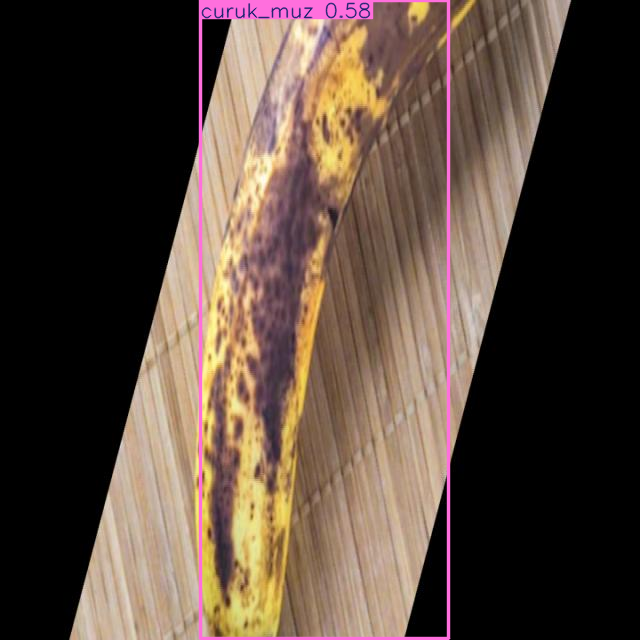


image 1/1 /content/master_dataset/valid/images/00_Patlican_18_jpg.rf.5eb54733f1bf67604f95c9641da75896.jpg: 640x640 1 patlican, 9.3ms
Speed: 1.7ms preprocess, 9.3ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)
📷 Test Edilen: 00_Patlican_18_jpg.rf.5eb54733f1bf67604f95c9641da75896.jpg


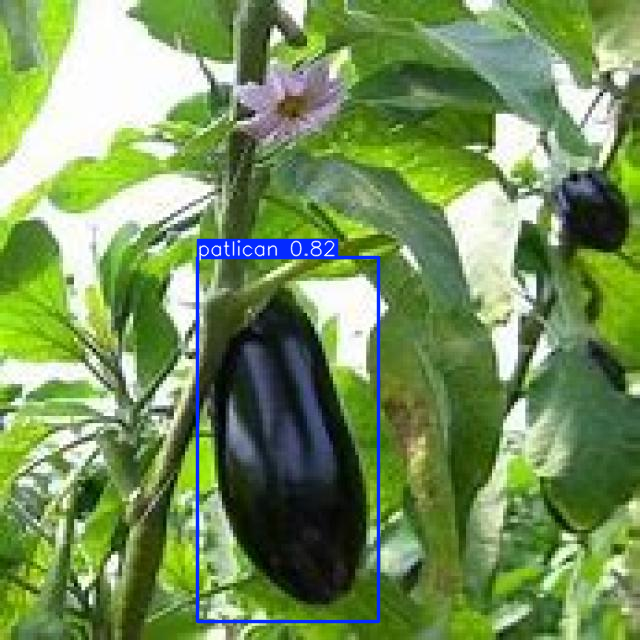


image 1/1 /content/master_dataset/valid/images/05_Curuk_Muz_rotated_by_75_Screen-Shot-2018-06-12-at-9-04-08-PM_png.rf.042ecc5f906a0736f77ab01eafd4f57a.jpg: 640x640 1 curuk_muz, 9.0ms
Speed: 1.8ms preprocess, 9.0ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 640)
📷 Test Edilen: 05_Curuk_Muz_rotated_by_75_Screen-Shot-2018-06-12-at-9-04-08-PM_png.rf.042ecc5f906a0736f77ab01eafd4f57a.jpg


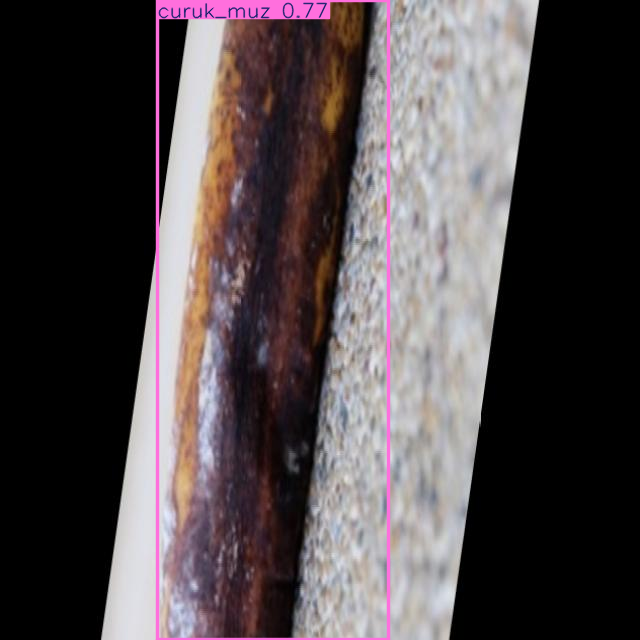

In [ ]:
import os
import random
import cv2
from google.colab.patches import cv2_imshow
from ultralytics import YOLO

# 1. Modeli Yükle
model_yolu = '/content/runs/detect/Manav_Asistani_Final_Model/weights/best.pt'
# model_yolu = '/content/drive/MyDrive/Manav_Asistani_Final_V2/Deneme_Final/weights/best.pt'

model = YOLO(model_yolu)

# 2. Test İçin Rastgele Resim Seçimi
test_img_dir = '/content/master_dataset/valid/images'
test_images = [os.path.join(test_img_dir, f) for f in os.listdir(test_img_dir) if f.endswith(('.jpg', '.png'))]
random_tests = random.sample(test_images, 3) # 3 tane rastgele seç

# 3. Tahmin Et ve Göster
for img_path in random_tests:
    results = model.predict(source=img_path, conf=0.5) # %50 güven üzerini göster

    # Sonuçları görselleştir
    res_plotted = results[0].plot()
    print(f"📷 Test Edilen: {os.path.basename(img_path)}")
    cv2_imshow(res_plotted)

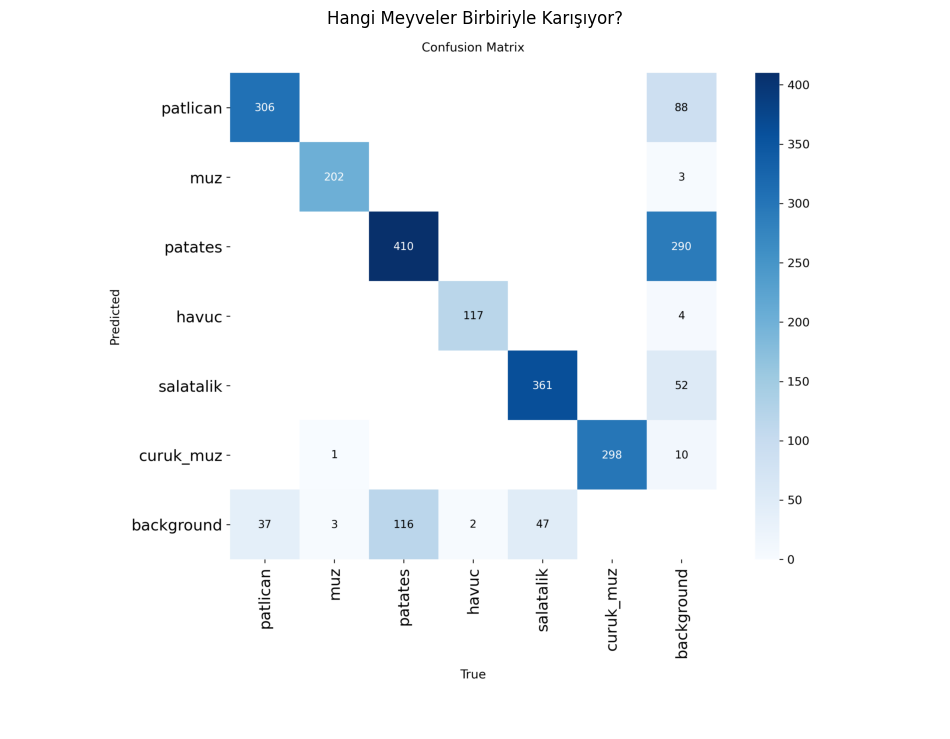

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Confusion Matrix yolunu bulma
conf_matrix_path = '/content/runs/detect/Manav_Asistani_Final_Model/confusion_matrix.png'

if os.path.exists(conf_matrix_path):
    img = mpimg.imread(conf_matrix_path)
    plt.figure(figsize=(12,10))
    plt.imshow(img)
    plt.axis('off')
    plt.title("Hangi Meyveler Birbiriyle Karışıyor?")
    plt.show()
else:
    print("⚠️ Confusion Matrix dosyası bulunamadı, eğitim klasörünü kontrol et.")

/tmp/ipykernel_9720/3439633641.py:48: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


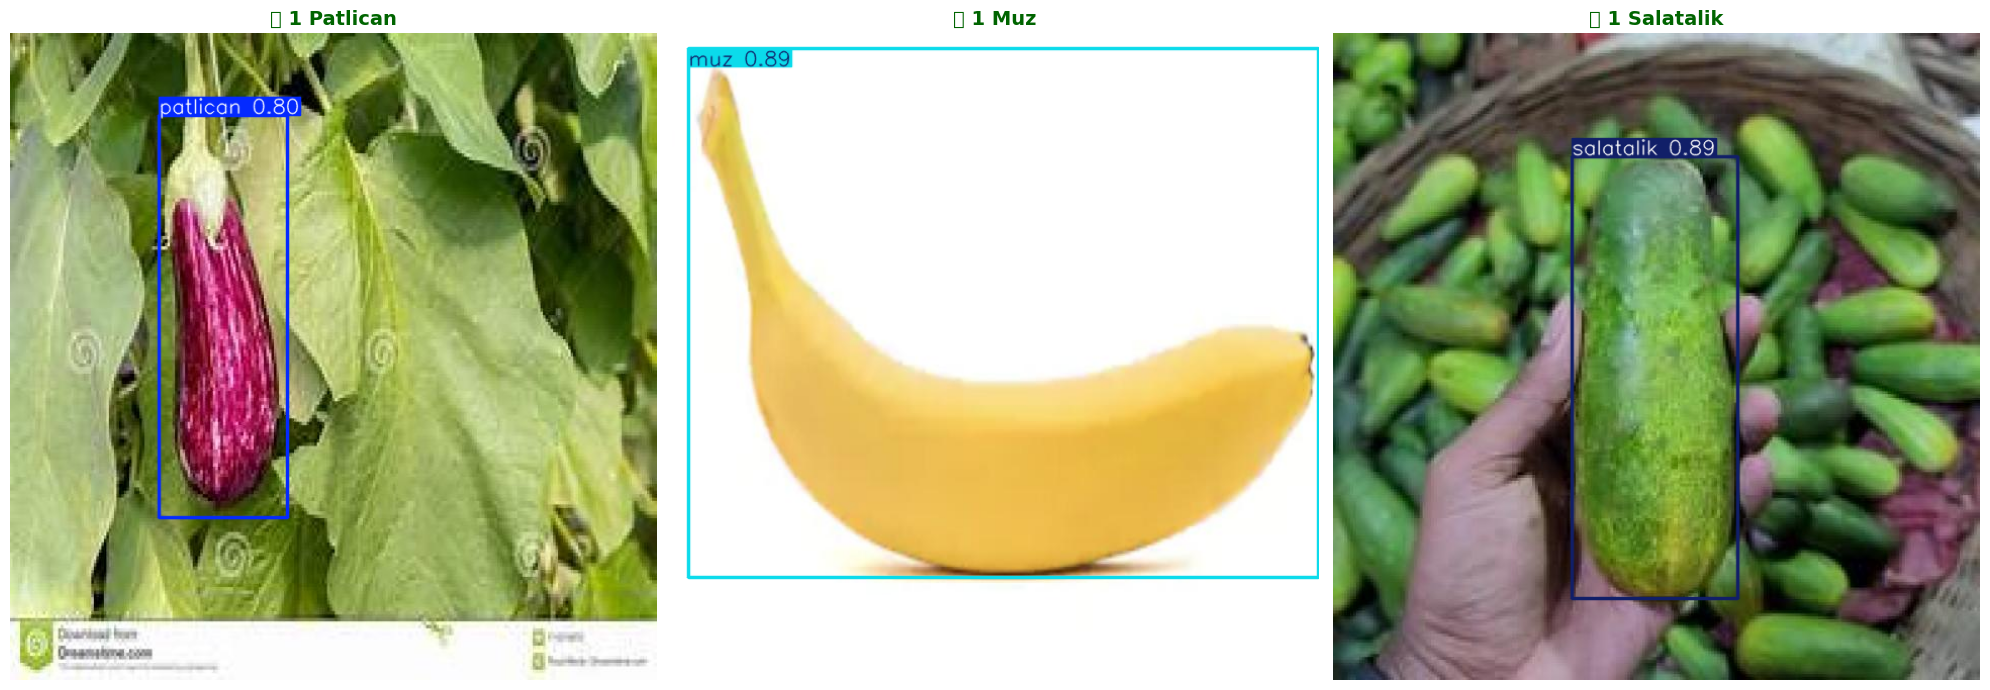

In [ ]:
import os
import random
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO
from collections import Counter

# 1. Modeli Yüklüyoruz
model_yolu = '/content/runs/detect/Manav_Asistani_Final_Model/weights/best.pt'

if not os.path.exists(model_yolu):
    model_yolu = 'best (3).pt'

model = YOLO(model_yolu)

# 2. Test İçin Resim Seçimi
test_img_dir = '/content/master_dataset/valid/images'
test_images = [os.path.join(test_img_dir, f) for f in os.listdir(test_img_dir) if f.endswith(('.jpg', '.png'))]
random_tests = random.sample(test_images, 3)

# 3. Görselleştirme
plt.figure(figsize=(20, 8)) # Resimlerin yan yana sığması için genişlik

for i, img_path in enumerate(random_tests):
    results = model.predict(source=img_path, conf=0.5, verbose=False)
    result = results[0]

    # Etiketleri sayalım
    found_classes = [result.names[int(cls)] for cls in result.boxes.cls]
    counts = Counter(found_classes)

    summary_title = ", ".join([f"{v} {k.capitalize()}" for k, v in counts.items()])
    if not summary_title:
        summary_title = "Nesne Bulunamadı"

    # Çizim
    img_plotted = result.plot(labels=True, conf=True)
    img_rgb = cv2.cvtColor(img_plotted, cv2.COLOR_BGR2RGB)

    plt.subplot(1, 3, i + 1)
    plt.imshow(img_rgb)
    plt.title(f"🔍 {summary_title}", fontsize=14, fontweight='bold', color='darkgreen')
    plt.axis('off')

plt.tight_layout()
plt.show()

/tmp/ipykernel_9720/3537466685.py:47: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


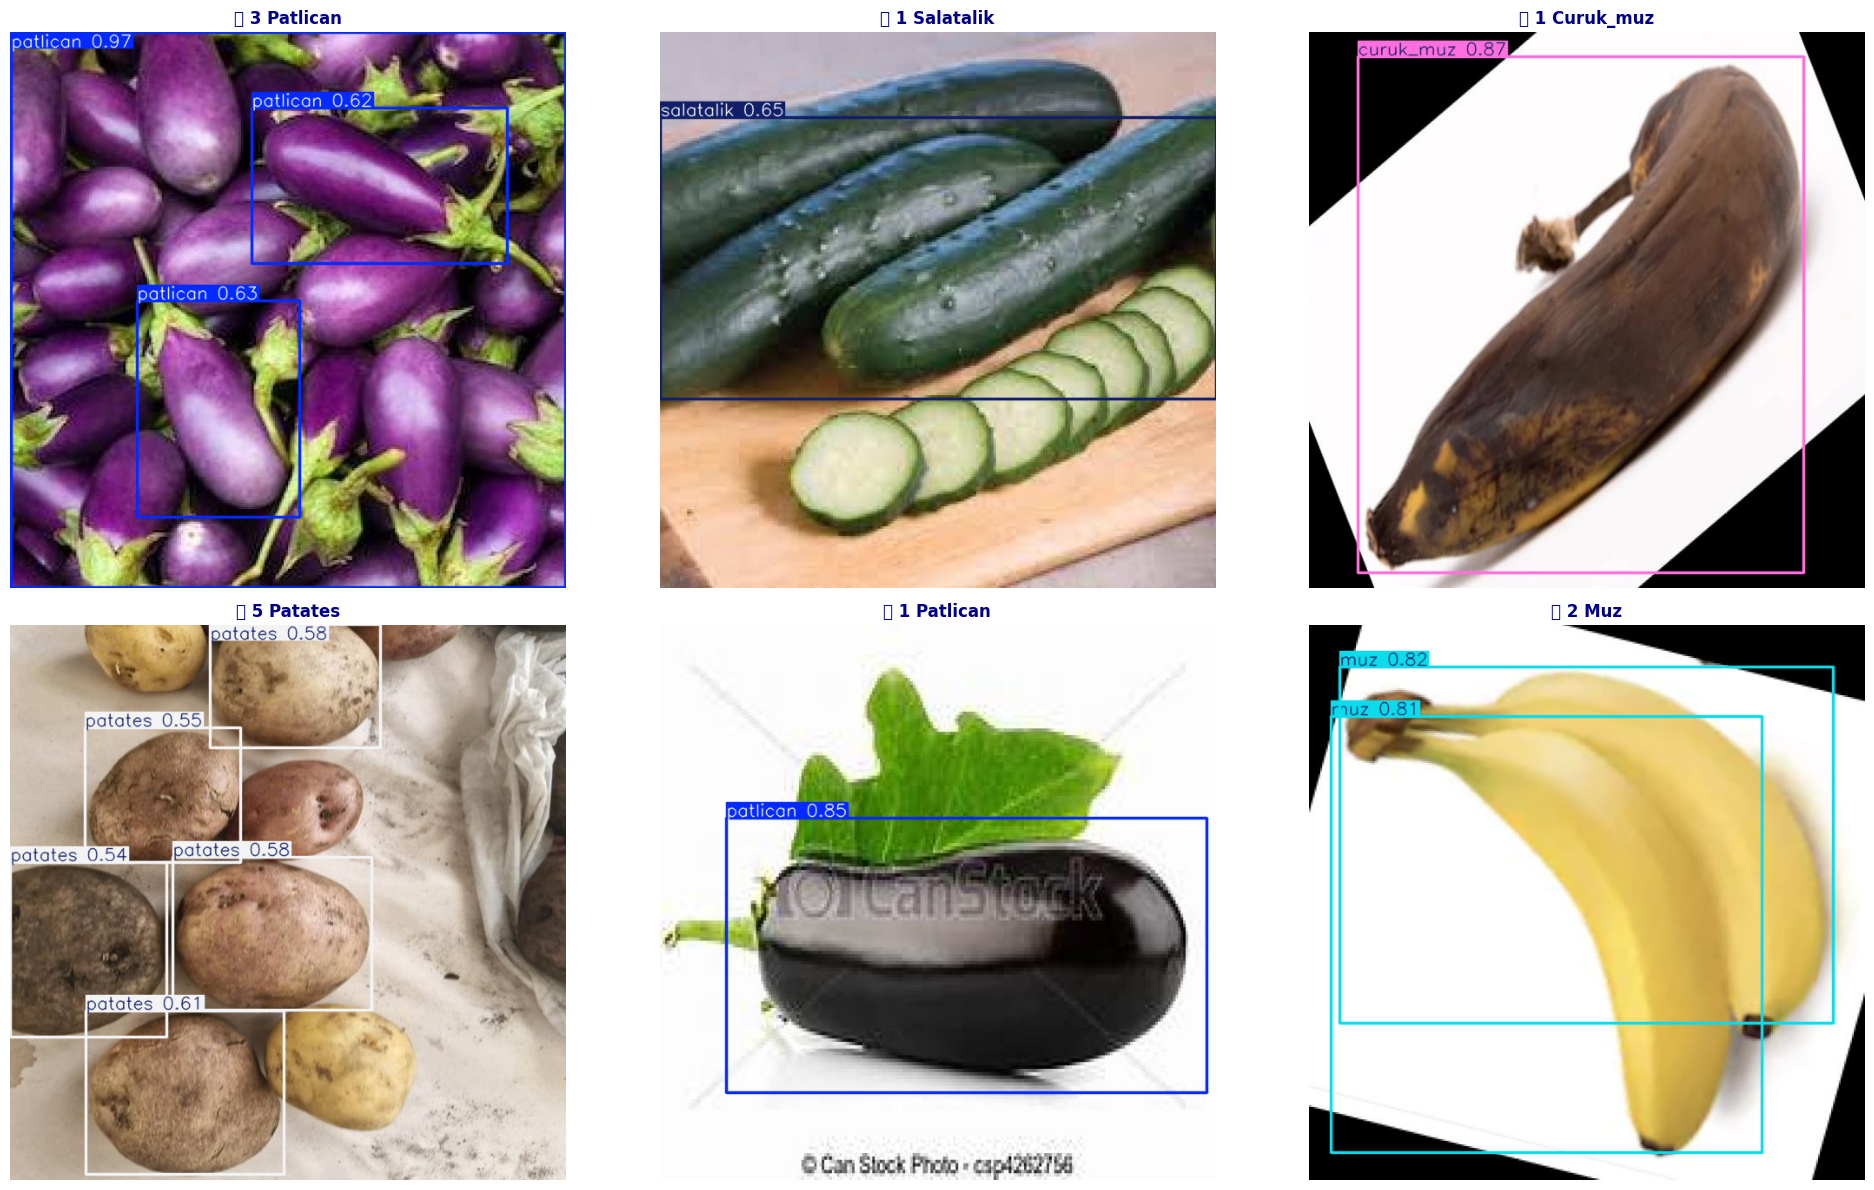

In [ ]:
import os
import random
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO
from collections import Counter

# 1. Modeli Yükle
model_yolu = '/content/runs/detect/Manav_Asistani_Final_Model/weights/best.pt'

if not os.path.exists(model_yolu):
    model_yolu = 'best (3).pt' # Alternatif isim kontrolü

model = YOLO(model_yolu)

# 2. Test İçin 6 Adet Resim Seç
test_img_dir = '/content/master_dataset/valid/images'
test_images = [os.path.join(test_img_dir, f) for f in os.listdir(test_img_dir) if f.endswith(('.jpg', '.png'))]
random_tests = random.sample(test_images, 6)

# 3. Görselleştirme (2 Satır, 3 Sütun)
plt.figure(figsize=(20, 12))

for i, img_path in enumerate(random_tests):
    results = model.predict(source=img_path, conf=0.5, verbose=False)
    result = results[0]

    # Etiketleri sayalım
    found_classes = [result.names[int(cls)] for cls in result.boxes.cls]
    counts = Counter(found_classes)

    # Başlık: "2 Muz, 1 Patates"
    summary_title = ", ".join([f"{v} {k.capitalize()}" for k, v in counts.items()])
    if not summary_title:
        summary_title = "Nesne Bulunamadı"

    # Tahminli resmi hazırla
    img_plotted = result.plot(labels=True, conf=True)
    img_rgb = cv2.cvtColor(img_plotted, cv2.COLOR_BGR2RGB)

    # 2 satır, 3 sütun düzeninde yerleştir
    plt.subplot(2, 3, i + 1)
    plt.imshow(img_rgb)
    plt.title(f"🔍 {summary_title}", fontsize=12, fontweight='bold', color='darkblue')
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
!pip install gradio

In [ ]:
import gradio as gr
from ultralytics import YOLO
import cv2
from collections import Counter

# 1. Modeli Yükle
model_yolu = '/content/runs/detect/Manav_Asistani_Final_Model/weights/best.pt'
model = YOLO(model_yolu)

def detect_objects(img):
    if img is None:
        return None, "Kamera bekleniyor..."

    # YOLO Tahmini (Gradio resmi zaten RGB verir, YOLO BGR bekler ama predict içinde halleder)
    results = model.predict(source=img, conf=0.5, verbose=False)
    result = results[0]

    # Sayım yapalım
    found_classes = [result.names[int(cls)] for cls in result.boxes.cls]
    counts = Counter(found_classes)

    # Özet metni
    summary = ", ".join([f"{v} {k.replace('_', ' ').capitalize()}" for k, v in counts.items()])
    if not summary:
        summary = "Meyve tespit edilemedi."

    # Kutucukların çizildiği resmi al
    annotated_img = result.plot()

    # YOLO BGR çıktı verir, Gradio RGB bekler. Çevirdim:
    annotated_img = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)

    return annotated_img, summary

# Arayüzü Yeni Sürüme Göre Oluştur
with gr.Blocks() as demo:
    gr.Markdown("## 🚀 Manav Asistanı Canlı Test")
    with gr.Row():
        # Yeni Gradio'da webcam bu şekilde tanımlanıyor:
        input_img = gr.Image(sources=["webcam"], streaming=True, type="numpy", label="Kamerayı Aç")
        output_img = gr.Image(label="YOLO Analizi")

    output_text = gr.Textbox(label="Tespit Edilen Meyveler")

    # Canlı akış için bağlantı
    input_img.stream(fn=detect_objects, inputs=input_img, outputs=[output_img, output_text])

# share=True
demo.launch(share=True, debug=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://cb0b8348d1469c29fa.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://cb0b8348d1469c29fa.gradio.live


In [ ]:
from ultralytics import YOLO
model = YOLO('/content/runs/detect/Manav_Asistani_Final_Model/weights/best.pt')
model.export(format='onnx') # Bu satır gerçek bir 'best.onnx' üretir

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.20GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
YOLOv8n summary (fused): 73 layers, 3,006,818 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from '/content/runs/detect/Manav_Asistani_Final_Model/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 10, 8400) (6.0 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 273ms
Prepared 4 packages in 3.46s
Installed 4 packages in 323ms
 + colorama==0.4.6
 + onnx==1.21.0
 + onnxruntime-gpu==1.25.0
 + onnxslim==0.1.91

requirements: AutoUpdate success ✅ 4.7s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.21.0 

'/content/runs/detect/Manav_Asistani_Final_Model/weights/best.onnx'